In [5]:
import inspect
from mpi4py import MPI
import petsc4py.PETSc as PETSc
import numpy as np

# FEniCSx Packages
import basix.ufl
import dolfinx
from dolfinx.fem.petsc import assemble_matrix, assemble_vector, create_vector, assign, set_bc, apply_lifting, LinearProblem
import ufl
from ufl import (
    jump, avg, inner, dot, grad, outer, FacetNormal, CellDiameter
)

In [2]:
def edge_mesh(v0, v1, N):
    nodes = np.zeros((N, 3), dtype=np.float64)
    nodes[:,0] = np.linspace(v0[0], v1[0], N)
    nodes[:,1] = np.linspace(v0[1], v1[1], N)
    nodes[0,2] = v0[2]
    nodes[-1,2] = v1[2]
    if v0[2] == 1:
        return nodes[1:,:]
    return nodes

comm = MPI.COMM_WORLD
N = 3

def assemble_graph_mesh(vertices, edge_connections, N, comm):
    if comm.rank == 0:
        nodes = np.zeros((0, 3), dtype=np.float64)
        connectivity = np.zeros((0, 2))
        for i in range(edge_connections.shape[0]):
            v0 = vertices[edge_connections[i, 0],:]
            v1 = vertices[edge_connections[i, 1],:]
            new_nodes = edge_mesh(v0, v1, N)
            nodes = np.concatenate((nodes, new_nodes))
        vertex_ids = np.where(nodes[:,2] != 0)[0]
        for i in range(edge_connections.shape[0]):
            if i == 0:
                v0 = vertex_ids[edge_connections[i, 0]]
                v1 = vertex_ids[edge_connections[i, 1]]
                local_connectivity_array = np.repeat(np.arange(v0, v1+1), 2)[1:-1]
                connectivity = np.concatenate((connectivity, local_connectivity_array.reshape(N-1, 2)))
            else:
                v0 = vertex_ids[edge_connections[i, 0]]
                v1 = vertex_ids[edge_connections[i, 1]]
                v_prev = vertex_ids[edge_connections[i-1, 1]]
                local_connectivity_array = np.repeat(np.arange(v_prev, v1+1), 2)[1:-1]
                local_connectivity_array[0] = v0
                connectivity = np.concatenate((connectivity, local_connectivity_array.reshape(N-1, 2)))
    else:
        nodes = np.zeros((0, 2), dtype=np.float64)
        connectivity = np.zeros((0, 2), dtype=np.int64)
    return nodes, connectivity

# Create 1D Graph Mesh Connectivity
N = 4

vertices = np.array([
    [0, 0, 2],
    [0, 0.5, 1],
    [0, 1, 2],
])

edges = np.array([
    [0, 1],
    [1, 2],
])

nodes_type, connectivity = assemble_graph_mesh(vertices, edges, N, comm)
nodes = nodes_type[:,:-1]


In [7]:
print(connectivity)

[[0. 1.]
 [1. 2.]
 [2. 3.]
 [3. 4.]
 [4. 5.]
 [5. 6.]
 [3. 7.]
 [7. 8.]
 [8. 9.]]


In [3]:
c_el = ufl.Mesh(basix.ufl.element("Lagrange", "interval", 1, shape=(2,)))

graph_mesh = dolfinx.mesh.create_mesh(
    comm, cells=connectivity, x=nodes, e=c_el
)

/tmp/ipykernel_45821/2335328213.py:44: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


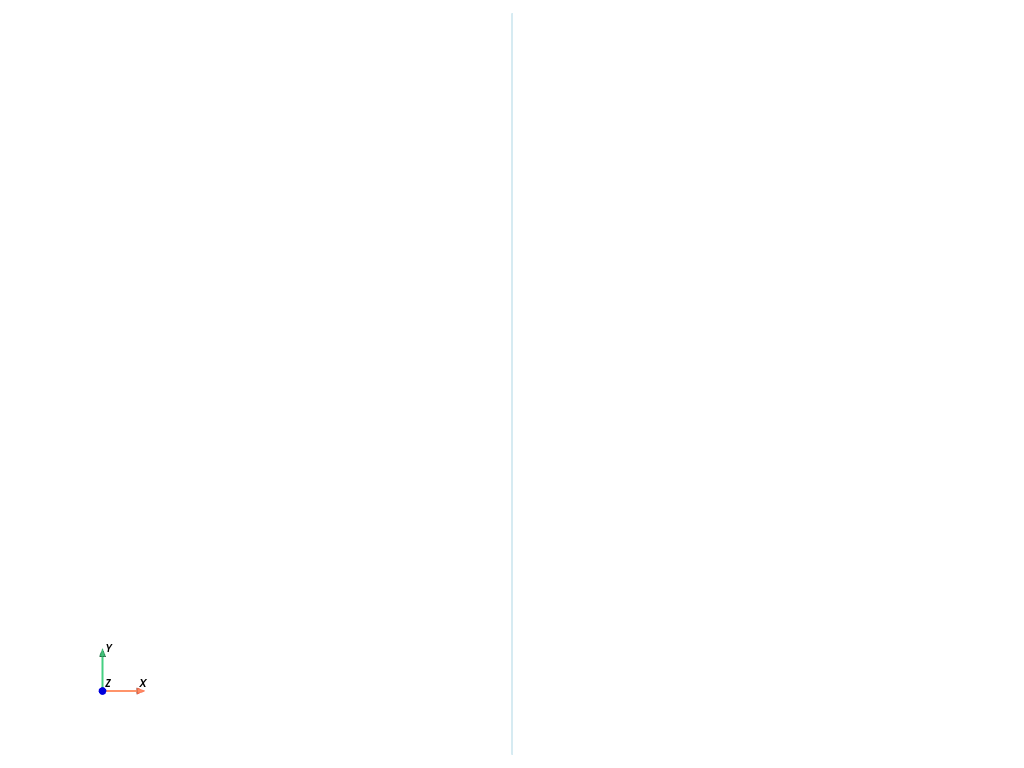

In [4]:
"""
Given a DOLFINx mesh, create a `pyvista.UnstructuredGrid`,
and plot it and the mesh nodes.

Args:
    mesh: The mesh we want to visualize
    values: List of values indicating a marker for each cell in the mesh

Note:
    If `values` are given as input, they are assumed to be a marker
    for each cell in the domain.
"""

import pyvista
values = None

# We create a pyvista plotter instance
plotter = pyvista.Plotter()

# Since the meshes might be created with higher order elements,
# we start by creating a linearized mesh for nicely inspecting the triangulation.
V_linear = dolfinx.fem.functionspace(graph_mesh, ("Lagrange", 1))
linear_grid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(V_linear))

# If the mesh is higher order, we plot the nodes on the exterior boundaries,
# as well as the mesh itself (with filled in cell markers)
if graph_mesh.geometry.cmap.degree > 1:
    ugrid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(graph_mesh))
    if values is not None:
        ugrid.cell_data["Marker"] = values
    plotter.add_mesh(ugrid, style="points", color="black", point_size=10)
    ugrid = ugrid.tessellate()
    plotter.add_mesh(ugrid, show_edges=True)
    plotter.add_mesh(linear_grid, style="wireframe", color="black")
else:
    # If the mesh is linear we add in the cell markers
    if values is not None:
        linear_grid.cell_data["Marker"] = values
    plotter.add_mesh(linear_grid, show_edges=True)

# We plot the coordinate axis and align it with the xy-plane
plotter.show_axes()
plotter.view_xy()
plotter.show()


In [7]:
# Define function Spaces

U = dolfinx.fem.functionspace(graph_mesh, ("CG", 1))

u = ufl.TrialFunction(U)
v = ufl.TestFunction(U)

dx_graph = ufl.Measure("dx", domain=graph_mesh)

In [ ]:
# Define true solution
x = ufl.SpatialCoordinate(graph_mesh)
u0 = ufl.sin(2 * ufl.pi * x[1])
f = 4 * (ufl.pi ** 2) * ufl.sin(2 * ufl.pi * x[1])

a = grad(u) * grad(v) * dx_graph
L = f * grad(v) * dx_graph

ValueError: Invalid ranks 1 and 1 in product.

In [ ]:
petsc_options = {
    "ksp_type": "cg",
    "pc_type": "lu",
    "ksp_rtol": 1e-6,
}
problem = LinearProblem(
    a, 
    L, 
    petsc_options_prefix="coupled_passion_",
    petsc_options=petsc_options,
)

uh = problem.solve()

In [4]:
# Identify Bifrucation Nodes
bifrucation_node_ids = np.where(nodes_type[:,2]==1)[0]
boundary_node_ids = np.where(nodes_type[:,2]==2)[0]
bifrucation_node_list = nodes[bifrucation_node_ids]
boundary_node_list = nodes[boundary_node_ids]
num_bifrucation_nodes = bifrucation_node_list.shape[0]
num_boundary_nodes = boundary_node_list.shape[0]
bifrucation_node_list = np.concatenate((bifrucation_node_list, np.zeros((num_bifrucation_nodes, 1))), axis=1)
boundary_node_list = np.concatenate((boundary_node_list, np.zeros((num_boundary_nodes, 1))), axis=1)

def bifrucation_nodes(x, y=bifrucation_node_list):
    x = x.T
    return np.isclose(x.reshape(x.shape[0], x.shape[1], 1), y.T.reshape(1, y.shape[0], y.shape[1])).all(axis=1).any(axis=1)

def boundary_nodes(x):
    return np.isclose(x[1], 0) | np.isclose(x[1], 3)

# Create Submesh on Bifrucation Nodes
tdim = graph_mesh.topology.dim
fdim = tdim - 1
graph_mesh.topology.create_connectivity(fdim, fdim)
bifrucation_cells = dolfinx.mesh.locate_entities(
    graph_mesh, fdim, bifrucation_nodes
)

boundary_facets = dolfinx.mesh.locate_entities_boundary(
    graph_mesh, fdim, boundary_nodes
)

bifrucation_node_mesh, entity_map, vertex_map, geom_map = dolfinx.mesh.create_submesh(
    graph_mesh, fdim, bifrucation_cells
)

# Create Marker for Bifrucation Nodes
cell_map = graph_mesh.topology.index_map(fdim)
num_cells = cell_map.size_local + cell_map.num_ghosts
all_cells = np.arange(num_cells, dtype=np.int32)
marker = np.ones(num_cells, dtype=np.int32)
marker[bifrucation_cells] = 2

# Create Meshtag to mark bifruncation nodes
cell_tag = dolfinx.mesh.meshtags(graph_mesh, fdim, all_cells, marker)

In [5]:
# Define Function Spaces
U = dolfinx.fem.functionspace(graph_mesh, ("DG", 1))
V = dolfinx.fem.functionspace(bifrucation_node_mesh, ("DG", 0))

# Trial and Test functions
W = ufl.MixedFunctionSpace(*[U, V])
uhat, utilde = ufl.TrialFunctions(W)
what, wtilde = ufl.TestFunctions(W)

# Measures
dx_graph = ufl.Measure("dx", domain=graph_mesh)
dS_graph = ufl.Measure("dS", domain=graph_mesh, subdomain_data=cell_tag)
ds_graph = ufl.Measure("ds", domain=graph_mesh, subdomain_data=cell_tag)

dx_bifruc = ufl.Measure("dx", domain=bifrucation_node_mesh)

# Constants
R = 0.05
A = ufl.pi * R ** 2
P = 2 * ufl.pi * R

# Facet Normal/Cell Diameter
n_graph = FacetNormal(graph_mesh)
h_graph = CellDiameter(graph_mesh)


In [6]:
# True Solution
x = ufl.SpatialCoordinate(graph_mesh)
u0 = x[1] + ufl.cos(2 * ufl.pi * x[1])
u1 = 2 + 0.5 * ufl.sqrt(2) * (x[1] - 1)
u3 = 2 + ufl.sqrt(2) / 2 + ufl.sqrt(5) * (x[1] - 2) / 8
u_true = ufl.conditional(x[1] <= 1, u0, ufl.conditional(x[1] <= 2, u1, u3))

# RHS Function
fhat = ufl.conditional(x[1] <= 1, 4 * ufl.pi ** 2 * ufl.cos(2 * ufl.pi * x[1]), 0)

In [ ]:
# Penalty Parameters
sigma_e = 30
sigma_v = 30

# Bilinear Forms
a_00 = A * inner(grad(uhat), grad(what)) * dx_graph \
    - A * inner(avg(grad(uhat)), jump(what, n_graph)) * dS_graph(1) \
    - A * inner(avg(grad(what)), jump(uhat, n_graph)) * dS_graph(1) \
    + (sigma_e / avg(h_graph)) * inner(jump(what, n_graph), jump(uhat, n_graph)) * dS_graph(1)

a_11 = (
    A * dot(grad(uhat), n_graph) * (what - wtilde) * ds_graph
    + A * dot (grad(what), n_graph) * (uhat - utilde) * ds_graph
    + (sigma_v / avg(h_graph)) * inner(uhat - utilde, what - wtilde) * dx_bifruc
)

a = a_00 + a_11

# RHS Linear Forms

f_vol = dolfinx.fem.Function(U)
f_expr = dolfinx.fem.Expression(fhat, U.element.interpolation_points)
f_vol.interpolate(f_expr)

L = A * inner(f_vol, what) * dx_graph
L += inner(dolfinx.fem.Constant(bifrucation_node_mesh, PETSc.ScalarType(0.0)), wtilde) * dx_bifruc

In [ ]:
t(bifrucation_node_mesh, PETSc.ScalarType(0.0)), wtilde) * dx_bifruc

In [16]:
ufl.extract_blocks(a)

((Form([Integral(Product(Product(Argument(FunctionSpace(Mesh(blocked element (Basix element (P, interval, 1, gll_warped, unset, False, float64, []), (2,)), 0), Basix element (P, interval, 1, gll_warped, unset, True, float64, [])), 1, 0), Conj(Argument(FunctionSpace(Mesh(blocked element (Basix element (P, interval, 1, gll_warped, unset, False, float64, []), (2,)), 0), Basix element (P, interval, 1, gll_warped, unset, True, float64, [])), 0, 0))), Division(IntValue(30), Product(FloatValue(0.5), Sum(PositiveRestricted(CellDiameter(Mesh(blocked element (Basix element (P, interval, 1, gll_warped, unset, False, float64, []), (2,)), 0))), NegativeRestricted(CellDiameter(Mesh(blocked element (Basix element (P, interval, 1, gll_warped, unset, False, float64, []), (2,)), 0))))))), 'cell', Mesh(blocked element (Basix element (P, point, 0, unset, unset, False, float64, []), (2,)), 1), 'everywhere', {}, None), Integral(Product(FloatValue(0.007853981633974483), Conj(Inner(Grad(Argument(FunctionSpace

In [8]:
boundary_facets = dolfinx.mesh.locate_entities_boundary(graph_mesh, fdim, boundary_nodes)
dofs = dolfinx.fem.locate_dofs_topological(U, fdim, boundary_facets)
bc_expr = dolfinx.fem.Expression(u_true, U.element.interpolation_points)
u_bc = dolfinx.fem.Function(U)
u_bc.interpolate(bc_expr)
bc = dolfinx.fem.dirichletbc(u_bc, dofs)

In [9]:
a_blocked = dolfinx.fem.form(ufl.extract_blocks(a), entity_maps=[entity_map])
L_blocked = dolfinx.fem.form(ufl.extract_blocks(L))

Amat = assemble_matrix(a_blocked, bcs=[bc])
Amat.assemble()

b = assemble_vector(L_blocked)

bcs1 = dolfinx.fem.bcs_by_block(dolfinx.fem.extract_function_spaces(a_blocked, 1), [bc])
apply_lifting(b, a_blocked, bcs=bcs1)
b.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
bcs0 = dolfinx.fem.bcs_by_block(dolfinx.fem.extract_function_spaces(L_blocked), [bc])
set_bc(b, bcs0)

# Boundary Conditions
#boundary_facets = dolfinx.mesh.locate_entities_boundary(graph_mesh, fdim, boundary_nodes)
#dofs = dolfinx.fem.locate_dofs_topological(V, fdim, boundary_facets)

ValueError: too many values to unpack (expected 1)

In [12]:
Amat.view()

Mat Object: 1 MPI process
  type: seqaij
row 0: (0, 80.4984)  (1, -0.0105372)  (2, -0.0105372)  (3, -80.4774) 
row 1: (0, -0.0105372)  (1, 0.0210744)  (2, 0.)  (3, -0.0105372) 
row 2: (0, -0.0105372)  (1, 0.)  (2, 80.4984)  (3, -6.93889e-18)  (4, -0.0105372)  (5, -80.4774) 
row 3: (0, -80.4774)  (1, -0.0105372)  (2, -6.93889e-18)  (3, 80.4984)  (4, 0.)  (5, -0.0105372) 
row 4: (2, -0.0105372)  (3, 0.)  (4, 0.0210744)  (5, -0.0105372) 
row 5: (2, -80.4774)  (3, -0.0105372)  (4, -0.0105372)  (5, 80.4984) 
row 6: (6, 63.6396)  (7, -0.00833041)  (10, -0.00833041)  (11, -63.6229) 
row 7: (6, -0.00833041)  (7, 0.0166608)  (10, 0.)  (11, -0.00833041) 
row 8: (8, 0.0210744)  (9, -0.0105372)  (12, -0.0105372)  (13, 0.) 
row 9: (8, -0.0105372)  (9, 80.4984)  (12, -80.4774)  (13, -0.0105372) 
row 10: (6, -0.00833041)  (7, 0.)  (10, 63.6396)  (11, -3.46945e-18)  (14, -0.00833041)  (15, -63.6229) 
row 11: (6, -63.6229)  (7, -0.00833041)  (10, -3.46945e-18)  (11, 63.6396)  (14, 0.)  (15, -0.00833041

In [13]:
m, n = Amat.getSizes()[0]
A_np = Amat.getValues(range(m), range(n))

k = b.getSizes()[0]
b_np = b.getValues(range(k))

print(np.linalg.det(A_np))

-1.560283372310835e-109


In [102]:
ksp = PETSc.KSP().create(graph_mesh.comm)
ksp.setOperators(Amat)
ksp.setType("preonly")
ksp.getPC().setType("lu")
ksp.getPC().setFactorSolverType("superlu_dist")

try:
    x = create_vector([U, V])
    ksp.solve(b, x)
    ksp.destroy()
    x.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)
    b.destroy()
except PETSc.Error as e:  # type: ignore
    if e.ierr == 92:
        print("The required PETSc solver/preconditioner is not available. Exiting.")
        print(e)
        exit(0)
    else:
        raise e

Error: error code 60
[0] KSPSolve() at /home/conda/feedstock_root/build_artifacts/bld/rattler-build_petsc_1775112133/work/src/ksp/ksp/interface/itfunc.c:1092
[0] KSPSolve_Private() at /home/conda/feedstock_root/build_artifacts/bld/rattler-build_petsc_1775112133/work/src/ksp/ksp/interface/itfunc.c:913
[0] KSPSolve_PREONLY() at /home/conda/feedstock_root/build_artifacts/bld/rattler-build_petsc_1775112133/work/src/ksp/ksp/impls/preonly/preonly.c:27
[0] KSP_PCApply() at /home/conda/feedstock_root/build_artifacts/bld/rattler-build_petsc_1775112133/work/include/petsc/private/kspimpl.h:413
[0] PCApply() at /home/conda/feedstock_root/build_artifacts/bld/rattler-build_petsc_1775112133/work/src/ksp/pc/interface/precon.c:518
[0] Nonconforming object sizes
[0] Preconditioner number of local rows 42 does not equal input vector size 45

In [82]:
x.view()

Vec Object: 1 MPI process
  type: mpi
Process [0]
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.
0.


In [83]:
uh, uh_tilde = dolfinx.fem.Function(U, name="uh"), dolfinx.fem.Function(V, name="uh_tilde")
assign(x, [uh, uh_tilde])
x.destroy()

In [84]:
def norm_L2(v: ufl.core.expr.Expr, measure: ufl.Measure = ufl.dx) -> np.inexact:
    """Convenience function to compute the L2 norm of a UFL expression."""
    compiled_form = dolfinx.fem.form(ufl.inner(v, v) * measure)
    comm = compiled_form.mesh.comm
    return np.sqrt(comm.allreduce(dolfinx.fem.assemble_scalar(compiled_form), op=MPI.SUM))

norm_L2(uh - u_true, dx_graph)

np.float64(7.272723983597343)